# Stage 6 — cross-validated dimensionality (bi-cross-validation)

Error-vs-#components curves from `src/06_dimensionality.py`. Bi-cross-validation
holds out neuron AND time blocks, so — unlike a scree plot — the curve can rise
again past the true dimensionality. The **minimum** is the estimated linear
reconstruction dimensionality; a minimum sitting at the sweep edge is **censored**
(true dimensionality is at least that large, limited here by neuron count).

`cv_error` = fraction of held-out variance left unexplained (lower is better;
1.0 = no better than the mean).


## Setup

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "config.py").exists():
        sys.path.insert(0, str(_p / "src")); break
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import DATA_PROCESSED, BIN_SIZE_S
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
COND_COLOR = {"all": "0.5", "novel": "tab:red", "familiar": "tab:blue"}
df = pd.read_csv(DATA_PROCESSED / f"stage6_dimensionality_{BIN_MS}ms.csv")
print("rows:", len(df), "| subjects:", df.subject.nunique())

rows: 777 | subjects: 5


## 1. Reconstruction-error curves (all sessions)

One panel per region; each thin line is one subject×condition. Dots mark each
curve's minimum; a ✕ marks minima that are **censored** (at the sweep edge).

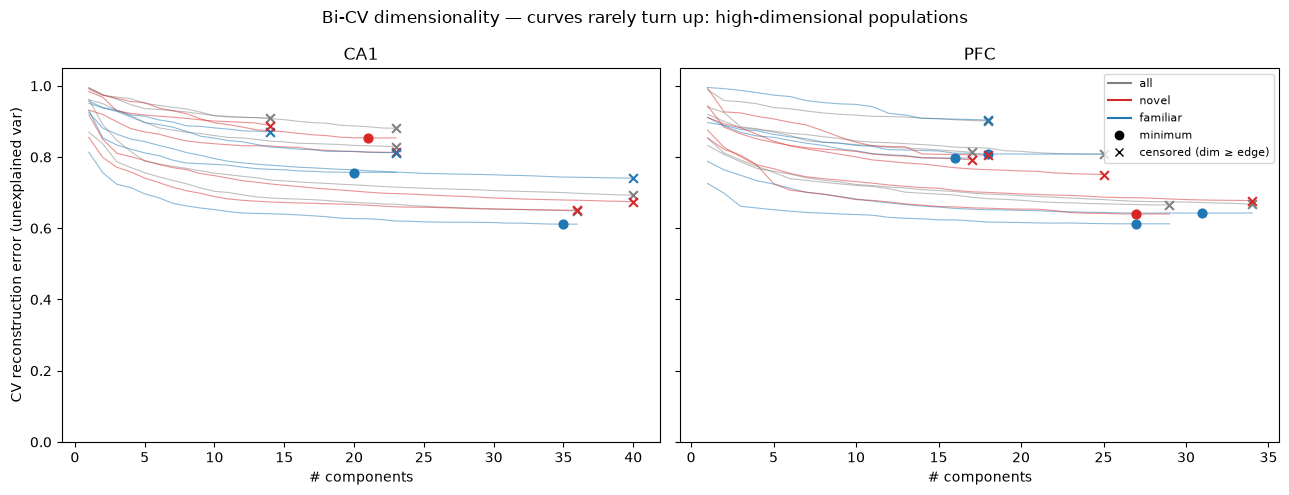

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, region in zip(axes, ["CA1", "PFC"]):
    sub = df[df.region == region]
    for (s, c), g in sub.groupby(["subject", "condition"]):
        g = g.sort_values("dim")
        ax.plot(g.dim, g.cv_error, color=COND_COLOR[c], lw=0.8, alpha=0.5)
        imin = g.cv_error.idxmin()
        censored = bool(g.loc[imin, "censored"])
        ax.scatter(g.loc[imin, "dim"], g.loc[imin, "cv_error"],
                   marker="x" if censored else "o",
                   color=COND_COLOR[c], s=40, zorder=3)
    ax.set_title(region); ax.set_xlabel("# components"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("CV reconstruction error (unexplained var)")
handles = [plt.Line2D([0], [0], color=v, label=k) for k, v in COND_COLOR.items()]
handles += [plt.Line2D([0], [0], marker="o", color="k", ls="", label="minimum"),
            plt.Line2D([0], [0], marker="x", color="k", ls="", label="censored (dim ≥ edge)")]
axes[1].legend(handles=handles, fontsize=8)
fig.suptitle("Bi-CV dimensionality — curves rarely turn up: high-dimensional populations")
plt.tight_layout()

## 2. Estimated optimal dimension per session
Hatched bars are censored (a lower bound, not a true minimum).

median_optimal  frac_censored
region condition                               
CA1    all                  23.0            1.0
       familiar             23.0            0.6
       novel                23.0            0.8
PFC    all                  25.0            1.0
       familiar             18.0            0.2
       novel                25.0            0.8

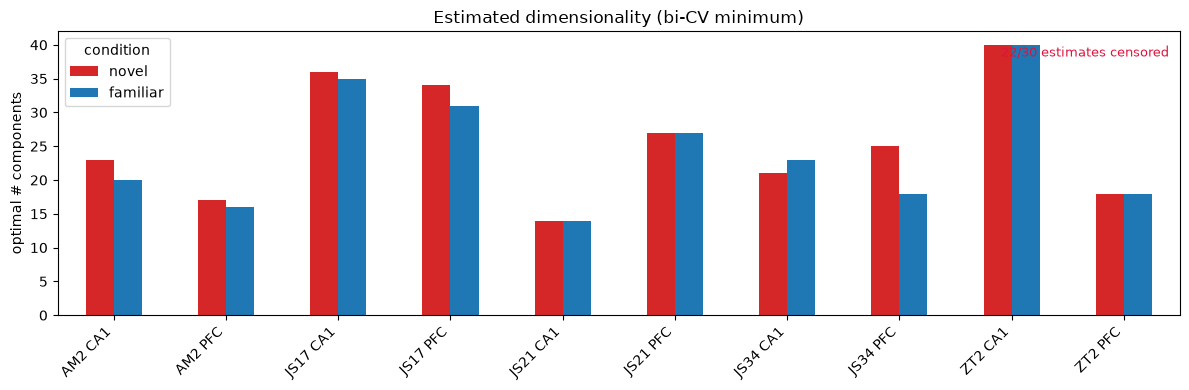

In [3]:
opt = df.drop_duplicates(["subject", "region", "condition"]).copy()
opt["label"] = opt.subject.str.split("-").str[-1] + " " + opt.region
piv = opt.pivot_table(index="label", columns="condition", values="optimal_dim")
cen = opt.pivot_table(index="label", columns="condition", values="censored")
ax = piv[["novel", "familiar"]].plot.bar(figsize=(12, 4),
        color=[COND_COLOR["novel"], COND_COLOR["familiar"]])
ax.set_ylabel("optimal # components"); ax.set_title("Estimated dimensionality (bi-CV minimum)")
ax.set_xlabel(""); plt.xticks(rotation=45, ha="right")
n_cens = int(opt["censored"].sum())
ax.text(0.99, 0.95, f"{n_cens}/{len(opt)} estimates censored",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="crimson")
plt.tight_layout()
opt.groupby(["region", "condition"]).agg(
    median_optimal=("optimal_dim", "median"),
    frac_censored=("censored", "mean")).round(2)

## 3. How much does the population compress?

For each session, the error at 3 components vs. at the best dimension — shows
that 3 linear PCs (the CEBRA embedding size) capture only part of the reconstructable
variance, even though 3-D CEBRA decodes position at R²≈0.9. The behaviorally
relevant signal is low-D; the *total* population is not.

,err_at_3,err_at_best,gap
region,,,
CA1,0.877,0.775,0.101
PFC,0.848,0.752,0.096


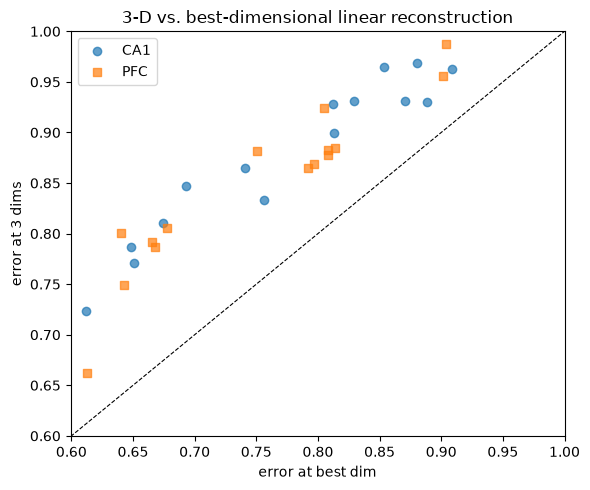

In [4]:
r3 = df[df.dim == 3].set_index(["subject", "region", "condition"])["cv_error"]
rbest = df.groupby(["subject", "region", "condition"])["cv_error"].min()
comp = pd.DataFrame({"err_at_3": r3, "err_at_best": rbest}).dropna()
comp["gap"] = comp.err_at_3 - comp.err_at_best
fig, ax = plt.subplots(figsize=(6, 5))
for region, mk in [("CA1", "o"), ("PFC", "s")]:
    m = comp.index.get_level_values("region") == region
    ax.scatter(comp.err_at_best[m], comp.err_at_3[m], marker=mk, label=region, alpha=0.7)
lim = [comp.values[:, :2].min() * 0.98, 1.0]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("error at best dim"); ax.set_ylabel("error at 3 dims"); ax.legend()
ax.set_title("3-D vs. best-dimensional linear reconstruction")
plt.tight_layout()
comp.groupby(level="region")[["err_at_3", "err_at_best", "gap"]].mean().round(3)

---
**Takeaway:** linear leave-neuron-out reconstruction shows these populations are
**high-dimensional at 1000 ms** — curves keep improving to the neuron-limited
edge (most estimates censored) and never reach a low-D floor. This does NOT
contradict the low-D CEBRA embeddings: CEBRA captures the *behaviorally relevant*
subspace (position, R²≈0.9 in 3-D), while most single-neuron variance is private
and not linearly reconstructable. Consider more neurons (pooling), finer bins, or
denoising if a crisp dimensionality estimate is needed.
